In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
cd drive/MyDrive/

/content/drive/MyDrive


In [ ]:
df = pd.read_csv('Smart-Warehouse-Delay/data/train.csv')
df

,ID,layout_id,scenario_id,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,heavy_item_ratio,cold_chain_ratio,sku_concentration,...,racking_height_avg_m,cross_dock_ratio,packaging_material_cost,quality_check_rate,outbound_truck_wait_min,dock_to_stock_hours,kpi_otd_pct,backorder_ratio,shift_handover_delay_min,sort_accuracy_pct
0,TRAIN_000000,WH_136,SC_07598,51.0,96.0,3.29,0.1176,0.1765,0.0392,0.3063,...,NaN,NaN,4.60,0.1443,8.1,7.92,86.6,0.0787,5.12,NaN
1,TRAIN_000001,WH_136,SC_07598,NaN,93.0,2.55,0.0597,NaN,0.0149,NaN,...,2.50,0.2490,5.22,0.1400,NaN,5.48,83.9,0.0850,5.77,94.88
2,TRAIN_000002,WH_136,SC_07598,92.0,115.0,2.49,0.0652,0.2283,0.0217,0.3063,...,3.87,0.1977,4.26,0.1817,10.7,6.88,82.1,0.1052,NaN,94.40
3,TRAIN_000003,WH_136,SC_07598,77.0,110.0,2.52,0.0649,NaN,0.0390,0.3063,...,2.50,0.1955,4.89,0.1485,10.7,6.76,87.9,0.0920,4.53,93.72
4,TRAIN_000004,WH_136,SC_07598,NaN,122.0,3.12,0.0667,0.3333,NaN,0.3063,...,NaN,0.2351,5.16,0.1514,12.4,9.03,83.8,0.0843,3.99,95.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,TRAIN_249995,WH_174,SC_05114,39.0,NaN,2.28,0.0513,0.1795,NaN,NaN,...,8.10,0.2586,4.17,0.0856,16.0,9.47,99.0,NaN,4.47,97.13
249996,TRAIN_249996,WH_174,SC_05114,69.0,96.0,2.22,0.0870,0.2319,0.0290,0.2226,...,8.63,0.2783,5.61,0.0526,19.6,11.41,NaN,0.0438,NaN,96.73
249997,TRAIN_249997,WH_174,SC_05114,61.0,123.0,2.62,0.0984,0.3934,0.0820,0.2226,...,NaN,0.2659,4.94,0.0379,16.5,13.26,95.9,NaN,3.24,98.86
249998,TRAIN_249998,WH_174,SC_05114,54.0,97.0,2.65,0.1296,0.1667,0.0185,0.2226,...,9.39,0.1736,4.40,0.0320,20.2,11.04,98.7,0.0519,1.97,98.63


#
### **📦 6. 창고 작업 효율**
* pack_utilization → 포장 작업 활용률
* replenishment_overlap → 보충 작업 겹침 정도
* manual_override_ratio → 수동 개입 비율
* staging_area_util → 적치 공간 활용률
* loading_dock_util → 도크 사용률
* conveyor_speed_mps → 컨베이어 속도
* pallet_wrap_time_min → 팔레트 포장 시간

In [ ]:
operation = df[["pack_utilization","replenishment_overlap","manual_override_ratio",
        "staging_area_util","loading_dock_util",
        "conveyor_speed_mps","pallet_wrap_time_min"]]
operation

,pack_utilization,replenishment_overlap,manual_override_ratio,staging_area_util,loading_dock_util,conveyor_speed_mps,pallet_wrap_time_min
0,0.3187,0.0867,0.0144,0.6683,0.6268,NaN,6.35
1,0.4188,NaN,0.0144,0.5904,NaN,1.49,5.39
2,0.5750,0.0014,0.0144,0.5863,0.6566,1.52,5.97
3,0.4813,0.0406,0.0144,0.6972,0.6594,1.51,6.13
4,0.3750,0.0082,0.0144,0.4822,0.6422,1.74,5.82
...,...,...,...,...,...,...,...
249995,0.2086,0.0265,0.0617,0.6516,0.2949,1.40,2.97
249996,0.3690,0.0000,0.0617,0.4401,0.3498,1.51,3.45
249997,0.3262,0.0000,0.0617,0.4140,0.4470,1.58,3.64
249998,NaN,0.0405,0.0617,0.5165,0.4757,NaN,2.80


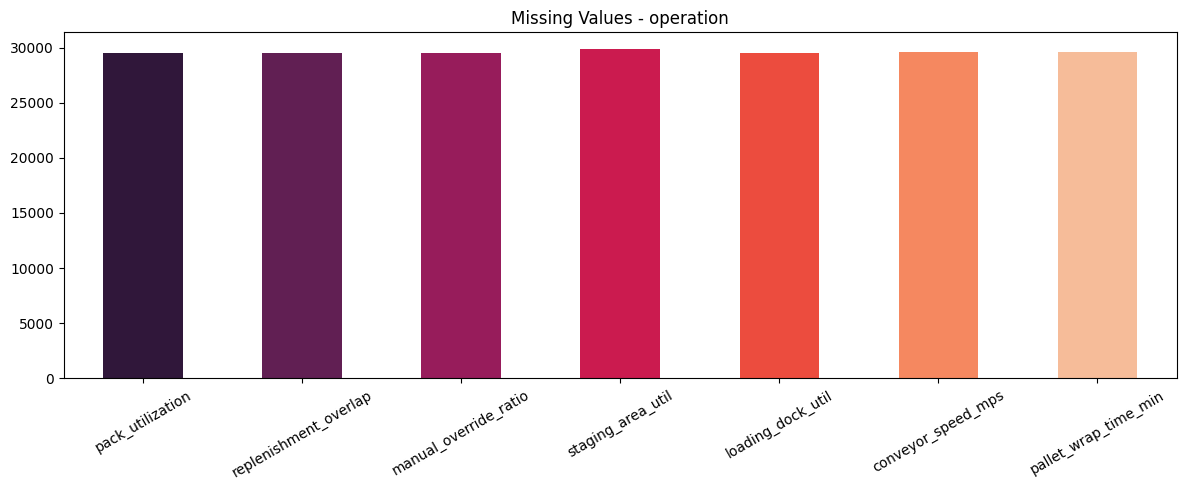

In [ ]:
missing = operation.isnull().sum()

colors = sns.color_palette("rocket", len(missing))

plt.figure(figsize=(12, 5))
missing.plot(kind='bar', color=colors)

plt.title('Missing Values - operation')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#
### **상관관계 분석**
* 상관관계가 없는 것으로 판단

In [ ]:
corr = operation.corr()
corr

,pack_utilization,replenishment_overlap,manual_override_ratio,staging_area_util,loading_dock_util,conveyor_speed_mps,pallet_wrap_time_min
pack_utilization,1.000000,-0.049433,-0.056237,0.184940,0.218671,-0.623907,-0.109598
replenishment_overlap,-0.049433,1.000000,0.340514,0.116032,0.147458,0.033811,0.013114
manual_override_ratio,-0.056237,0.340514,1.000000,0.118783,0.147811,0.036644,0.021560
staging_area_util,0.184940,0.116032,0.118783,1.000000,0.263881,-0.105469,-0.042350
loading_dock_util,0.218671,0.147458,0.147811,0.263881,1.000000,-0.139940,-0.039765
conveyor_speed_mps,-0.623907,0.033811,0.036644,-0.105469,-0.139940,1.000000,0.068181
pallet_wrap_time_min,-0.109598,0.013114,0.021560,-0.042350,-0.039765,0.068181,1.000000


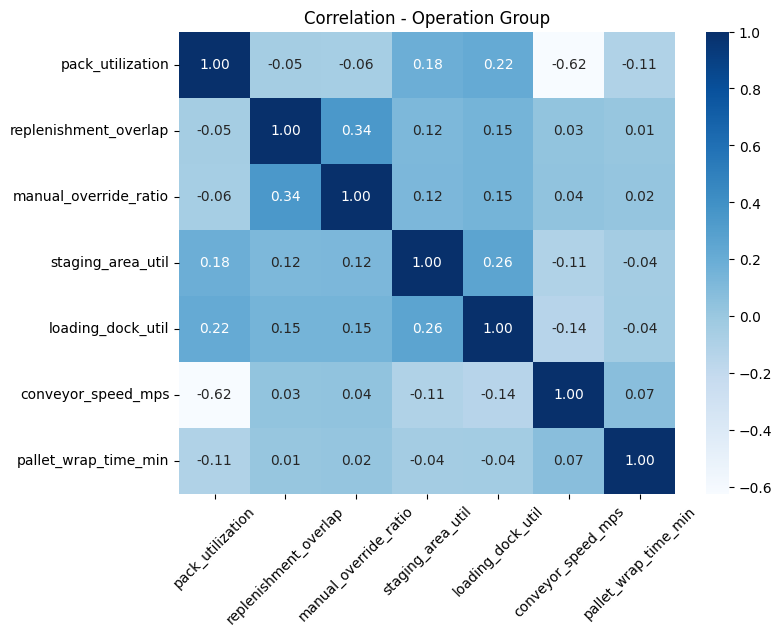

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f")

plt.title('Correlation - Operation Group')
plt.xticks(rotation=45)
plt.show()